# 1-Bit HHL track simulation toy model 64 particles 7 layers

This Jupyter notebook is compatible with Python 3.13, Qiskit v2.2, Qiskit Aer v0.17, Qiskit runtime version: 0.43 and Qiskit Runtime V2 primitives.
|||
|-|-|
|**Author:** |Alain Chancé|
|**Date:** |September 29, 2025|
|**Version:** |**1.00**|
An efficient implementation of the 1-Bit HHL track simulation toy model at the LHCb at CERN derived from the following publications:
- [Alain Chancé, A Toy Model For Reconstructing Particle Tracks at LHCb at CERN with Quantum Computing, 30 Oct. 2025, LHCb_VeLo_Toy_Model_1-Bit_HHL.pdf](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/LHCb_VeLo_Toy_Model_1-Bit_HHL.pdf).
- [Xenofon Chiotopoulos, Davide Nicotra, George Scriven, Kurt Driessens, Marcel Merk, Jochen Schütz, Jacco de Vries, Mark H.M. Winands, TrackHHL: The 1-Bit Quantum Filter for particle trajectory reconstruction, 12 Jan 2026, arXiv:2601.07766](https://doi.org/10.48550/arXiv.2601.07766)
- [Xenofon Chiotopoulos, TrackHHL: A Quantum Computing Algorithm for Track Reconstruction at the LHCb](https://indico.cern.ch/event/1338689/contributions/6010017/attachments/2951297/5188722/CHEP_ppt.pdf)
- Xenofon Chiotopoulos, Miriam Lucio Martinez, Davide Nicotra, Jacco A. de Vries, Kurt Driessens, Marcel Merk, and Mark H.M. Winands, TrackHHL: A Quantum Computing Algorithm for Track Reconstruction at the LHCb, EPJ Web of Conferences 337, 01181 (2025), [https://doi.org/10.1051/epjconf/202533701181](https://doi.org/10.1051/epjconf/202533701181).
- [D. Nicotra et al., arXiv:2308.00619v2, 7 Oct 2023, A quantum algorithm for track reconstruction in the LHCb vertex detector](https://arxiv.org/pdf/2308.00619).

## Import libraries

In [1]:
import matplotlib.pyplot as plt

In [2]:
from One_Bit_HHL_Simulation import One_Bit_HHL

Qiskit version: 2.2.3
Qiskit Aer version: 0.17.2
Qiskit runtime version: 0.43.1


## Setup configuration parameters

In [3]:
config = {
    #--------------------
    # Simulation options
    #--------------------
    "dz": 20,                           # layer spacing (mm)
    "layers": 7,                        # Number of layers
    "n_particles": [16, 16, 16, 16],    # Number of particles
    "p_vertices": [(0,0,4), (0,0,6), (0,0,8), (0,0,10)],  # Primary vertices
    "do_draw": False,                    # Whether to draw the HHL circuit
    "measurement_error": 0.0,           # HIT RESOLUTION (sigma on measurement) (sigma)
    "collision_noise": 0.0,             # MULTIPLE SCATTERING (angular noise proxy)
    "ghost_rate": 1e-2,                 # Ghost (fake) track rate
    "drop_rate": 0.0,                   # Hit drop (inefficiency) rate
    "display_particles": False,         # Whether to display initial particle states
    "display_hits": False,              # Whether to display hits
    "display_ghost_hits": True,         # Whether to display ghost hits
    "display_tracks": True,             # Whether to display events and ghost tracks
    "display_clusters": False,          # Whether to display clusters found by find_tracks()
    "display_false_clusters": True,     # Whether to display clusters rejected by find_tracks()
    "do_plot_tracks": True,             # Whether to plot events and ghost tracks 
    "do_solve_scipy": False,            # Whether to solve classically using scipy.sparse.linalg.cg
    "T_classical": None,                # Threshold for discretizing classical solutions
    "T_hhl": None,                      # Threshold for discretizing 1-Bit HHL solutions - None: to be computed
    "do_spectrum": False,               # Whether to analyze the classical solution spectrum
    "do_print_counts": False,           # Whether to print raw measurement counts
    "do_print_outer_segs": True,        # Whether to print segments in modules greater than 3
    "tol": 1e-6,                        # Tolerance for floating point comparison
    #------------------------------------------
    # Files containing token (API key) and CRN
    #------------------------------------------
    "token_file": "Token.txt",          # Token file
    "CRN_file": "CRN.txt",              # CRN file
    #-------------
    # Run options
    #-------------
    "backend_name": "AerSimulator noiseless",           # AerSimulator noiseless or Fake QPU or real IBM cloud backend name
    "job_id": None,                                     # job_id of a previously run job
    "run_on_QPU": True,                                 # Whether to run the quantum circuit on the target hardware
    "nshots": 500000,                                   # Number of shots
    'opt_level': 1,                                     # Optimization level
    "poll_interval": 5,                                 # Poll interval in seconds for job monitor
    "timeout": 600,                                     # Time out in seconds for job monitor
    #-------------------------------------
    # eco2AI Tracker options
    # https://github.com/sb-ai-lab/Eco2AI
    #-------------------------------------
    "do_eco2ai": True,                                   # Whether to use the eco2AI Tracker
    "project_name": "One_Bit_HHL",                       # Project name
    "experiment_description": "HHL_64_p_7_l_noiseless",  # Experiment description
    "eco2ai_file_name": "HHL_64_p_7_l_noiseless.csv",    # eco2AI file name
    #---------------------------------------------------------------------------------
    # Ballpark figure (kW) for the power consumption of the IBM cloud backend
    # "The power consumption of a quantum computer is about 15-25kW"
    # https://www.capgemini.com/insights/expert-perspectives/green-quantum-computing/
    #---------------------------------------------------------------------------------
    "power_QPU": 25,                    # Ballpark figure (kW) for the power consumption of the IBM cloud backend
}

## Create an instance of the One_Bit_HHL class from the configuration dictionary

In [4]:
try:
    My_HHL = One_Bit_HHL(**config)
except Exception as e:
   print(f"Error creating 1_Bit_HHL instance: {e}")


Simulation options
layer spacing (mm), dz: 20
layers: 7
n_particles: [16, 16, 16, 16], Total number: 64
primary_vertices: [(0, 0, 4), (0, 0, 6), (0, 0, 8), (0, 0, 10)]
do_draw: False
measurement hit resolution: 0.0
multiple scattering collision noise: 0.0
ghost (fake) track rate: 0.01
hit drop (inefficiency) rate: 0.0
display_particles: False
display_hits: False
display_ghost_hits: True
display_tracks: True
display_clusters: False
display_false_clusters: True
do_plot_tracks: True
do_plot_heat_map: True
do_solve_scipy: False
T_classical: None
T_hhl: None
do_spectrum: False
do_print_counts: False
do_print_outer_segs True
resolution: 25
tol: 1e-06

Run options
Backend name: AerSimulator noiseless
Run on QPU: True
Number of shots: 500000
Optimization level: 1

eco2AI Tracker options
project_name: One_Bit_HHL
experiment_description: HHL_64_p_7_l_noiseless
eco2ai_file_name: HHL_64_p_7_l_noiseless.csv

Ballpark figure (kW) for QPU power consumption: 25

Deleted: HHL_64_p_7_l_noiseless.csv
ec

## Setup events


----------------------------------------------------------------
 All    4 ghost hits created by the function make_noisy_event()
----------------------------------------------------------------

     Hit ID       x         y         z       Theta      Module ID
       0        -2.96    -14.83    100.00    -1.768          5
       0         9.10    -12.78     20.00    -0.952          1
       0        -4.01     14.73     60.00     1.836          3
       0         1.74     -2.68    140.00    -0.996          7

--------------
 Event tracks
--------------

Track ID: 0
     Hit ID       x         y         z       Theta      Module ID
       0         0.86      0.62     20.00     0.622          1
       1         1.93      1.38     40.00     0.622          2
       2         3.00      2.15     60.00     0.622          3
       3         4.08      2.92     80.00     0.622          4
       4         5.15      3.69    100.00     0.622          5
       5         6.22      4.46    120.00    

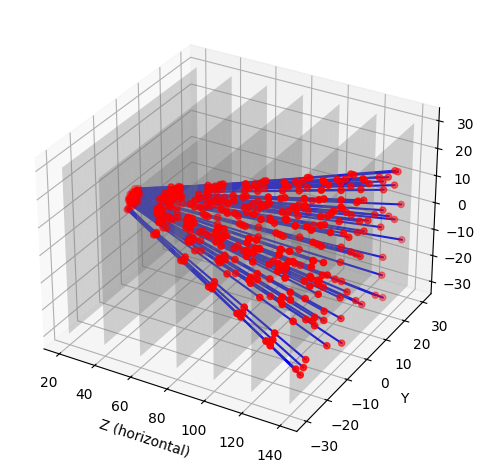


Plotting event tracks with ghost hits (false tracks)


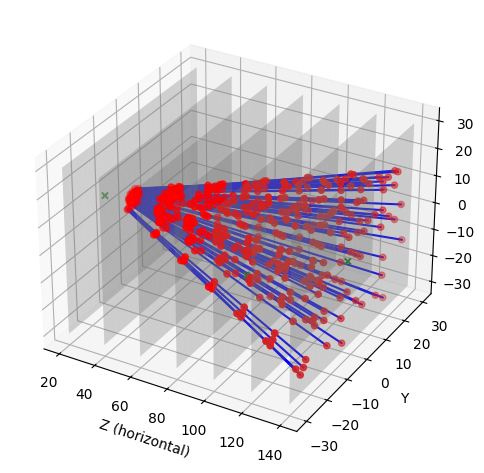

In [5]:
My_HHL.setup_events()

## Run classical and 1-Bit HHL simulations


----------------------------------------------------
 find_tracks() found 64 tracks and 4 false clusters
----------------------------------------------------

----------------------------------------------------------------
 All    4 false clusters rejected by the function find_tracks()
----------------------------------------------------------------

  Hit ID       x         y         z       Theta    Module ID
    0        -2.96    -14.83    100.00    -1.768       5
    0         1.74     -2.68    140.00    -0.996       7
    0         9.10    -12.78     20.00    -0.952       1
    0        -4.01     14.73     60.00     1.836       3

------------------------------------------------
 All tracks found by the function find_tracks()
------------------------------------------------

Track ID: 0
     Hit ID       x         y         z       Theta      Module ID
       0         0.86      0.62     20.00     0.622          1
       1         1.93      1.38     40.00     0.622          2
  

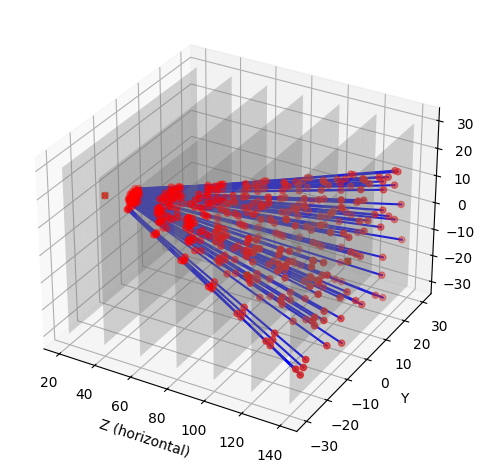


------------------------------------------------------------
 construct_segments() method of the SimpleHamiltonian class
------------------------------------------------------------

Function construct_segments() - Adding segments with matching theta to segment_in_indices

    Segment ID        Hits           Theta         Module ID
       0            0      1         0.622            2
      65            7      8         3.019            2
     130           14     15        -1.316            2
     195           21     22        -2.284            2
     260           28     29         1.347            2
     325           35     36        -1.227            2
     390           42     43        -1.038            2
     455           49     50         0.146            2
     520           56     57         0.735            2
     585           63     64        -2.189            2
     650           70     71        -1.309            2
     715           77     78         1.370      

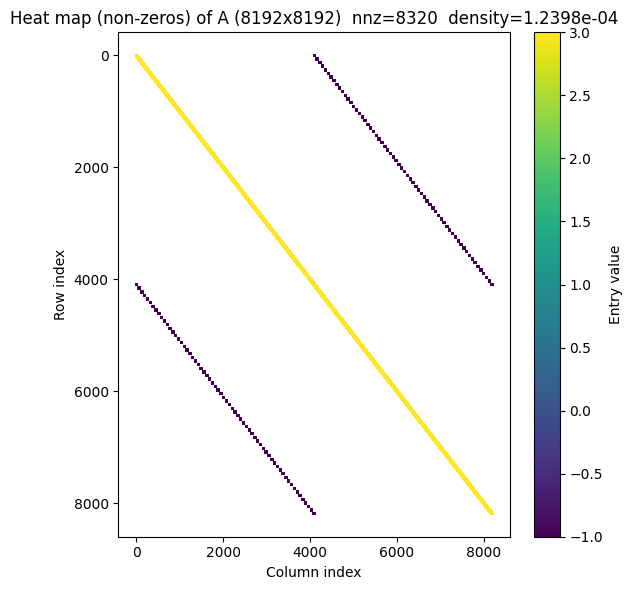


-------------------------------------------------------
 1-Bit HHL simulation with only the first three layers
-------------------------------------------------------

Creating hhl_solver instance of the HHLAlgorithm as follows:
Number of time qubits: 1

Number of qubits in HHL circuit:  15
backend_name: AerSimulator noiseless

Using AerSimulator with method statevector and noiseless
Gate counts (w/ pre-init passes): OrderedDict({'cx': 23553, 'u2': 9232, 'tdg': 7680, 't': 7680, 'u1': 512, 'u3': 512, 'x': 489, 'measure': 14, 'h': 1})

The depth of the isa quantum circuit is: 43018
Gate statistics for the circuit:
OrderedDict({'cx': 23553, 'p': 15872, 'u': 10234, 'measure': 14})

Simulating with AerSimulator

Extracted HHL solution (normalized):
[0.08532462 0.         0.         ... 0.         0.         0.09674903]

Computed T_hhl: 0.022803964585835362

Discretized HHL solution:
[1 0 0 ... 0 0 1]

Indices of HHL solution:
[0, 65, 130, 195, 260, 325, 390, 455, 520, 585, 650, 715, 780, 8

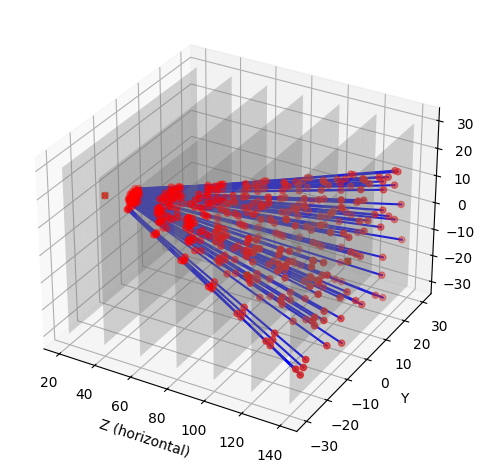


Classical processing - Duration (h): 0.0027 - Power consumption (kWh): 0.0000


In [6]:
My_HHL.run_simulation()

In [7]:
# Display Markdown file from the GitHub repository LHCb_VeLo_Toy_Model_1-Bit_HHL
import requests
from IPython.display import Markdown, display

url = "https://raw.githubusercontent.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/main/README.md"

response = requests.get(url)
response.raise_for_status()  # ensures errors are visible

display(Markdown(response.text))

# LHCb_VeLo_Toy_Model_1-Bit_HHL
An efficient implementation of the 1-Bit HHL track simulation toy model at the LHCb at CERN derived from the following publications:
- [Alain Chancé, A Toy Model For Reconstructing Particle Tracks at LHCb at CERN with Quantum Computing, 30 Oct. 2025, LHCb_VeLo_Toy_Model_1-Bit_HHL.pdf](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/LHCb_VeLo_Toy_Model_1-Bit_HHL.pdf).
- [Xenofon Chiotopoulos, Davide Nicotra, George Scriven, Kurt Driessens, Marcel Merk, Jochen Schütz, Jacco de Vries, Mark H.M. Winands, TrackHHL: The 1-Bit Quantum Filter for particle trajectory reconstruction, 12 Jan 2026, arXiv:2601.07766](https://doi.org/10.48550/arXiv.2601.07766)
- [Xenofon Chiotopoulos, TrackHHL: A Quantum Computing Algorithm for Track Reconstruction at the LHCb](https://indico.cern.ch/event/1338689/contributions/6010017/attachments/2951297/5188722/CHEP_ppt.pdf)
- Xenofon Chiotopoulos, Miriam Lucio Martinez, Davide Nicotra, Jacco A. de Vries, Kurt Driessens, Marcel Merk, and Mark H.M. Winands, TrackHHL: A Quantum Computing Algorithm for Track Reconstruction at the LHCb, EPJ Web of Conferences 337, 01181 (2025), [https://doi.org/10.1051/epjconf/202533701181](https://doi.org/10.1051/epjconf/202533701181).
- [D. Nicotra et al., arXiv:2308.00619v2, 7 Oct 2023, A quantum algorithm for track reconstruction in the LHCb vertex detector](https://arxiv.org/pdf/2308.00619)

## The Large Hadron Collider beauty (LHCb) experiment at CERN
The LHCb Experiment at CERN is a general-purpose detector at the Large Hadron Collider (LHC) and specializes in investigating the slight differences between matter and antimatter by studying a type of particle called the "beauty quark", or "b quark".

It uses a series of subdetectors to detect mainly forward particles – those thrown forwards by the collision in one direction. The first subdetector is mounted close to the collision point, with the others following one behind the other over a length of 20 meters.
The 5600-tonne LHCb detector is made up of a forward spectrometer and planar detectors. It is 21 meters long, 10 meters high and 13 meters wide, and sits 100 meters below ground near the town of Ferney-Voltaire, France. 

As of 2024, more than 1600 members from 98 institutes in 22 countries, including 1100 authors.
Source: https://home.cern/science/experiments/lhcb 

## Particle track reconstruction in the LHCb Vertex Locator (VELO)
In the High Luminosity phase of the Large Hadron Collider (HL-LHC), thousands of particles are produced simultaneously. Particles leave energy hits in detector layers. Hits are reconstructed into particle tracks. Tracks reveal Primary Vertices (collision points). Tracks in the LHCb Vertex Locator (VELO) can be modeled as straight lines intersecting the z-axis because it is the sub-detector closest to the LHCb collision point and it contains a negligible magnetic field.

## Classical sort-by-angle theta particle track reconstruction
In the XY projection, these straight lines pass through the origin. As a result, energy hits are likely to have a constant phase in polar coordinates when projected onto the XY plane (see Section 3, *Search by triplet — Sort by φ*, in [ALGO-10](https://arxiv.org/pdf/2207.03936)). We have developed the following functions:
- `cluster_by_last_column()`, which clusters hits by the last-column polar angle `theta` of an array of hits.
- `segment_intersects_z_axis()`, which checks whether a line intersects the z-axis and finds the corresponding primary vertex.  
- `find_tracks()`, which reconstructs tracks from these clusters and finds all primary vertices.

An example of output of `find_tracks()` follows:
```
--------------------------------------------------------------------------------------------------------
 Tracks found by the function find_tracks() from the clusters by last column theta of the array of hits
--------------------------------------------------------------------------------------------------------

find_tracks() found 2 tracks

Track ID: 0
     Hit ID       x         y         z       Theta      Module ID
       0        -0.32      0.52     20.00     2.127          1
       1        -0.97      1.55     40.00     2.127          2
       2        -1.61      2.59     60.00     2.127          3
       3        -2.25      3.62     80.00     2.127          4
       4        -2.90      4.66    100.00     2.127          5
       5        -3.54      5.69    120.00     2.127          6

    Segment ID        Hits           Theta         Module ID
       0            0      1         2.127            2
       1            1      2         2.127            3
       2            2      3         2.127            4
       3            3      4         2.127            5
       4            4      5         2.127            6

Track ID: 1
     Hit ID       x         y         z       Theta      Module ID
       6        -0.63      0.38     20.00     2.607          1
       7        -1.90      1.13     40.00     2.607          2
       8        -3.17      1.88     60.00     2.607          3
       9        -4.44      2.63     80.00     2.607          4
      10        -5.71      3.38    100.00     2.607          5
      11        -6.97      4.13    120.00     2.607          6

    Segment ID        Hits           Theta         Module ID
       0            6      7         2.607            2
       1            7      8         2.607            3
       2            8      9         2.607            4
       3            9     10         2.607            5
       4           10     11         2.607            6

Found primary vertices:
(0.0, 0.0, 10.0)
```

## Reconstructing tracks by Minimizing an Ising-like Hamiltonian using matrix inversion
The Hamiltonian $𝐻(𝑆)$ is parametrized in terms of doublets $𝑆$, these doublets are possible connections between two hits in subsequent detector layers and take a binary value to indicate if they actively contribute to a track, $S_i \in${0, 1}. It includes three terms:

- The angular term $𝐻_{𝑎𝑛𝑔}$ is the most important as it determines if a set of doublets $𝑆_𝑖$ and $𝑆_𝑗$ are aligned within $\varepsilon$.
- $𝐻_{spec}(𝑆)$ makes the spectrum of $A$ positive.
- $𝐻_{gap}(𝑆)$ ensures gap in the solution spectrum.

$$𝐻(𝑆) = 𝐻_{𝑎𝑛𝑔}(𝑆,\varepsilon)+\gamma𝐻_{spec}(𝑆)+\delta𝐻_{gap}(𝑆)$$

$$H_{\text{ang}}(S,\varepsilon) = -\frac{1}{2} \left[ \sum_{abc} f(\theta_{abc}, \varepsilon) S_{ab} S_{bc} \right]$$

$$𝐻_{spec}(𝑆)=\sum_{𝑎𝑏} 𝑆_{𝑎𝑏}^2$$

$$𝐻_{gap}(𝑆)=\sum_{𝑎𝑏} (1−2S_{𝑎𝑏})^2)$$

$$
f(\theta_{abc}, \varepsilon) =
\begin{cases}
1 & \text{if } \cos(\theta_{abc}) \geq 1 - \varepsilon \\
0 & \text{otherwise}
\end{cases}
$$

$$𝐻(𝑆)=−\frac{1}{2} \left[\sum_{abc} f(\theta_{abc}, \varepsilon) S_{ab} S_{bc} + \gamma\sum_{𝑎𝑏} 𝑆_{𝑎𝑏}^2 + \delta\sum_{𝑎𝑏} (1−2S_{𝑎𝑏} )^2\right]$$ 

By relaxing $𝑆_𝑖\inℝ$, we find its minimum by taking the derivative of the quadratic $𝐻$, obtaining a system of linear equations:

$$∇_𝑆 H=−AS+b=0,  AS=b$$

Matrix inversion yields the solution of reconstructed tracks. The resulting vector $𝑆$ of real values is subsequently discretized to obtain an "on"/"off" status by setting a threshold $𝑇$.

## Solving the system of linear equations classically
The system of linear equations $𝐴𝑆=𝑏$ is solved using [scipy.sparse.linalg.cg](https://docs.scipy.org/doc/scipy-1.12.0/reference/generated/scipy.sparse.linalg.cg.html):
```
sol, _ = sci.sparse.linalg.cg(A, vector_b, atol=0)
```
The discretized solution is obtained by setting a threshold `T_classical` in the list of configuration parameters `param`:
```
T_classical = param["T_classical"]
disc_sol = (sol > T_classical).astype(int)
```

## Solving the system of linear equations with the 1-Bit HHL algorithm
The Harrow–Hassidim–Lloyd (HHL) algorithm promises a complexity improvement over the best classical alternatives for solving sparse systems of linear equations. However, its practical implementation faces considerable challenges. The Quantum Phase Estimation (QPE) step results in prohibitively deep circuits, making the algorithm unfeasible on currently available hardware short of fault-tolerant quantum computing.

The 1-Bit HHL algorithm, presented in the paper [TrackHHL: A Quantum Computing Algorithm for Track Reconstruction at the LHCb](https://doi.org/10.1051/epjconf/202533701181), applies a first-order Suzuki–Trotter decomposition to approximate the time-evolution operator. By restricting the QPE accuracy to a single bit, the algorithm can efficiently determine whether a phase is close to zero or significantly different.

The discretized solution is obtained by setting a threshold `T_hhl` in the list of configuration parameters `param`:
```
T_hhl = param["T_hhl"]
disc_x_hhl = (x_hhl > T_hhl).astype(int)
```

# Efficient Implementation
This implementation uses only hits from the first three layers for both classical and 1-bit HHL simulations.

## Fast construction of the Hamiltonian $H(S)$
The function `construct_segments` is enhanced to identify segments with matching values of `theta` during their creation and to append them to the list `segment_in_indices`, along with their corresponding segment IDs in the list `segment_indices`. The function `construct_hamiltonian` then considers only doublets $S_i$ and $S_j$ of segments in `segment_in_indices` whose angular difference in `theta` is within $\varepsilon$. This modification significantly improves the performance of the preprocessing step.

## Smart error detection and recovery
The function `get_tracks_smart()` in  [One_Bit_HHL_Simulation.py](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/One_Bit_HHL_Simulation.py) performs the following steps:

- Identifies active segments in the first three layers from both the classical solution and the 1-bit HHL quantum solution.  
- Reconstructs tracks using only segments that intersect the z-axis; their intersection points define the reconstructed primary vertices.  
- Adds missed segments intersecting the z-axis and extends active segments to all outer layers.

# Installation

## Requirements
Be sure you have the following installed:

* Qiskit SDK v2.1 or later, with visualization support (`pip install 'qiskit[visualization]'`)
* 'qiskit-aer' library (`pip install qiskit-aer`)
* Qiskit runtime 0.40 or later (`pip install qiskit-ibm-runtime`)
* [eco2AI](https://github.com/sb-ai-lab/Eco2AI) is optional (`pip install eco2ai`)

## Clone the repository `LHCb_VeLo_Toy_Model_1-Bit_HHL`
`git clone https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL`

# Credits
The Jupyter notebooks in this repository [LHCb_VeLo_Toy_Model_1-Bit_HHL](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL) and the Python file [One_Bit_HHL_Simulation.py](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/One_Bit_HHL_Simulation.py) are derived from the following sources:

* GitHub repository [OneBQF](https://github.com/Xenofon-Chiotopoulos/OneBQF/tree/main) owned by Xenofon Chiotopoulos and more specifically:
   - Module [OneBQF.py](https://github.com/Xenofon-Chiotopoulos/OneBQF/blob/main/quantum_algorithms/OneBQF.py)
   - Jupyter notebook [example.ipynb](https://github.com/Xenofon-Chiotopoulos/OneBQF/blob/main/example.ipynb).

* Jupyter notebook [George_Sandbox.ipynb](https://github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model/blob/main/George_Sandbox.ipynb) owned by George William Scriven, [GeorgeWilliam1999](https://orcid.org/0009-0004-9997-1647).

* Relevant documentation can be found in the Jupyter notebook [Tracking Toy Model Demo](https://github.com/Xenofon-Chiotopoulos/Tracking_Toy_model/blob/main/example_notebook.ipynb) in the public repository [Tracking_Toy_model](https://github.com/Xenofon-Chiotopoulos/Tracking_Toy_model/tree/main) owned by Xenofon Chiotopoulos.

# Additions by Alain Chancé
## Energetics Analysis
* **Assumption:**
  A ballpark estimate for a typical modern IBM-class superconducting quantum computer (including cryogenics and supporting infrastructure, while idle or lightly used) is approximately **15–25 kW**.
  Source: [*Green Quantum Computing*, Capgemini, 8 May 2023](https://www.capgemini.com/insights/expert-perspectives/green-quantum-computing/).

* The `One_Bit_HHL` class integrates the [eco2AI](https://github.com/sb-ai-lab/Eco2AI) tracking feature, a python library which accumulates statistics about power consumption and CO2 emission during running code. The Eco2AI is licensed under a [Apache licence 2.0](https://www.apache.org/licenses/LICENSE-2.0).

## [One_Bit_HHL_Simulation.py](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/One_Bit_HHL_Simulation.py)
This module defines a new class `One_Bit_HHL`.

## New functions
The following functions are copied from the class SQD in [SQD_Alain.py](https://github.com/AlainChance/SQD_Alain/blob/main/SQD_Alain.py):
- setup_backend()
- check_size()
- get_QPU_usage()
- get_classical_power_usage()

The following function is derived from the module [OneBQF/toy_model/simple_hamiltonian.py](https://github.com/Xenofon-Chiotopoulos/OneBQF/blob/main/toy_model/simple_hamiltonian.py):
- find_segments() derived from function find_segments()

New functions:
- cluster_by_last_column()
- find_tracks()
- gen_indices()
- check_intersection()
- intersects_origin()
- intersects_z_axis()
- segment_intersects_z_axis()
- get_tracks_smart()
- display_tracks()
- display_p_vertices()
- plot_event()
- setup_Hamiltonian()
- classical_simulation()
- run_qc()
- HHL_simulation()
- run_simulation()

### Function cluster_by_last_column
This function clusters rows of a NumPy array whose last column values differ by less than `tol`. It uses NumPy plus sorting.

Input parameters:
- arr: NumPy array of floats
- tol: tolerance

Returns:
- list of rows clustered around the values of the last column.

```
    def cluster_by_last_column(self, arr, tol=1e-6):
        arr = np.asarray(arr)
        
        # Sort by last column
        idx = np.argsort(arr[:, -1])
        arr_sorted = arr[idx]
    
        clusters = []
        current_cluster = [arr_sorted[0]]
    
        for row in arr_sorted[1:]:
            if abs(row[-1] - current_cluster[-1][-1]) <= tol:
                current_cluster.append(row) 
            else: 
                clusters.append(np.array(current_cluster)) 
                current_cluster = [row] 
            
        clusters.append(np.array(current_cluster))
    
        return clusters
```

### Function find_tracks
This function finds tracks using the function `cluster_by_last_column()`, which find tracks from clusters rows of an array of hits around the polar coordinate $\theta$.

Input parameter:
- List of hits.

Input from the parameter list:
- layers: number of layers
- tol: tolerance
- do_plot_tracks
- resolution
- display_tracks
- display_clusters
- display_false_clusters
- ghost_hits (future use)

Returns in the parameter list:
- List of found tracks from rows of an array of hits clustered around the polar coordinate theta.
- List of found segments.
- Reconstructed event

Displays:
- Number of found tracks and false clusters.
- List of found clusters.
- List of false clusters rejected by the function find_tracks().
- list of found tracks.
- List of primary vertices.

Calls:
- cluster_by_last_column().
- display_tracks().
- display_p_vertices().

```
    #----------------------------------------------------------------------------------------------------
    # Define function find_tracks()
    #
    # This method finds tracks using the function `cluster_by_last_column()`, which clusters 
    # rows of an array of hits around the polar coordinate theta.
    # 
    # Input parameter:
    #  - List of hits.
    #
    # Input from the parameter list:
    # - layers: number of layers
    # - tol: tolerance
    # - do_plot_tracks
    # - resolution
    # - display_tracks
    # - display_clusters
    # - display_false_clusters
    # - ghost_hits (future use)
    #
    # Returns in the parameter list:
    #  - List of found tracks from rows of an array of hits clustered around the polar coordinate theta.
    #  - List of found segments.
    #  - Reconstructed event.
    #
    # Displays:
    #  - Number of found tracks and false clusters
    #  - List of found clusters.
    #  - List of false clusters rejected by the function find_tracks().
    #  - list of found tracks.
    #  - List of primary vertices.
    #
    # Calls
    #  - cluster_by_last_column()
    #  - display_tracks()
    #  - display_p_vertices()
    #
    # Author: Alain Chancé
    #----------------------------------------------------------------------------------------------------
    def find_tracks(self, list_hits):

        if self.param is None:
            print("find_tracks: missing parameter param")
            return None
        param = self.param

        layers = param["layers"]
        tol = param["tol"]
        do_plot_tracks = param["do_plot_tracks"]
        resolution = param["resolution"]
        display_tracks = param["display_tracks"]
        display_clusters = param["display_clusters"]
        display_false_clusters = param["display_false_clusters"]
        ghost_hits = param["ghost_hits"]

        if list_hits is None or list_hits == []:
            print("find_tracks: input list of hits is None or empty - Exiting with no found track")
            return 0
        
        #--------------------------------------------------------
        # Create a NumPy array of hits with theta as last column
        #--------------------------------------------------------
        array_hits = np.array([[hit.hit_id, hit.x, hit.y, hit.z, hit.module_id, hit.theta] for hit in list_hits], dtype=float)

        #------------------------------------------
        # Cluster by last column the array of hits
        #------------------------------------------
        clusters = self.cluster_by_last_column(array_hits, tol=tol)

        # Sort each cluster internally
        sorted_clusters = [c[np.argsort(c[:, 0])] for c in clusters]
        
        # Sort the list of clusters by the first column of the first row
        sorted_clusters = sorted(sorted_clusters, key=lambda c: c[0, 0])

        clusters = sorted_clusters

        #-------------------------------------------
        # Create a list of tracks from the clusters
        #-------------------------------------------
        false_clusters = []
        found_clusters = []
        found_tracks = []
        found_segments = []

        threshold = max(1, int(layers/2))
        
        k = 0
        for cluster in clusters:

            # Discard clusters of length less than half the number of layers
            if len(cluster) < threshold:
                false_clusters.append(cluster)
                continue

            found_clusters.append(cluster)

            # Create a new track
            track_hits = [hit for hit in list_hits if hit.hit_id in [int(x[0]) for x in cluster]][:layers]
            track_segs = []
            
            for idx in range(len(track_hits) - 1):

                s = Segment(
                    hits=[track_hits[idx], track_hits[idx + 1]],
                    segment_id=idx
                )
                
                track_segs.append(s)
                found_segments.append(s)
                    
            track = Track(
                track_id = k,
                hits = track_hits,
                segments = track_segs
            )

            # Find primary vertice
            self.segment_intersects_z_axis(track.segments[0], tol=tol)

            found_tracks.append(track)
            k += 1

        #---------------------------------------------------
        # Display number of found tracks and false clusters
        #---------------------------------------------------
        text = f" find_tracks() found {len(found_tracks)} tracks"
        if len(false_clusters) > 0:
            text += f" and {len(false_clusters)} false clusters"
        line = "-" * (len(text) + 1)
        print(f"\n{line}\n{text}\n{line}")

        #------------------------
        # Display found clusters
        #------------------------
        if display_clusters and len(found_clusters) > 0:

            print("\n--------------------------------------------------")
            print(f" All {len(found_clusters):4.0f} clusters found by find_tracks()")
            print("--------------------------------------------------")
            print(f"\n  Hit ID       x         y         z       Theta    Module ID")
            
            for cluster in found_clusters:
                for x in cluster:
                    print(f"    {x[0]:.0f}       {x[1]:6.2f}    {x[2]:6.2f}    {x[3]:6.2f}    {x[5]:6.3f}       {x[4]:.0f}")

        #------------------------
        # Display false clusters
        #------------------------
        if display_false_clusters and len(false_clusters) > 0:
            
            print("\n----------------------------------------------------------------")
            print(f" All {len(false_clusters):4.0f} false clusters rejected by the function find_tracks()")
            print("----------------------------------------------------------------")
            print(f"\n  Hit ID       x         y         z       Theta    Module ID")

            for cluster in false_clusters:
                for x in cluster:
                    print(f"    {x[0]:.0f}       {x[1]:6.2f}    {x[2]:6.2f}    {x[3]:6.2f}    {x[5]:6.3f}       {x[4]:.0f}")

        #----------------------
        # Display found tracks
        #----------------------
        if display_tracks and len(found_tracks) > 0:                       
            self.display_tracks(found_tracks, text=f" All tracks found by the function find_tracks()")

        #--------------------------
        # Display primary vertices
        #--------------------------
        self.display_p_vertices()

        #-----------------------------------------------------------------------------------------
        # Create an instance of the class Event defined in state_event_model.py
        # https://github.com/Xenofon-Chiotopoulos/OneBQF/blob/main/toy_model/state_event_model.py
        # Author: Alain Chancé
        #-----------------------------------------------------------------------------------------
        found_event = Event(
            detector_geometry = param["detector_geometry"],
            tracks = found_tracks,
            hits = param["hits"],
            segments = found_segments,
            modules = param["modules"]
        )
        param["found_event"] = found_event

        #---------------------------
        # Plot reconstructed tracks
        #---------------------------
        if do_plot_tracks:          
            print("\nPlotting reconstructed event tracks found by the function find_tracks()")
            self.plot_event(found_event, resolution)

        #------------------------------------------------------
        # Save found tracks and segments in the parameter list
        #------------------------------------------------------
        param["found_tracks"] = found_tracks
        param["found_segments"] = found_segments
        
        return
```

### Function gen_indices
The function `gen_indices()` generates ordered active segment indices as illustrated in Figure 2, left panel, of [ALGO-3](https://cds.cern.ch/record/2950969/files/document.pdf) identical to the one returned by the modified function `construct_segments` of the class SimpleHamiltonian.

The Jupyter notebook [Test_gen_indices.ipynb](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/Test_gen_indices.ipynb) generates the following list of segment indices for 2 to 8 particles and 3 layers:
```
Number of particles   Active segment indices
2                     [0, 3, 4, 7]
3                     [0, 4, 8, 9, 13, 17]
4                     [0, 5, 10, 15, 16, 21, 26, 31]
5                     [0, 6, 12, 18, 24, 25, 31, 37, 43, 49]
6                     [0, 7, 14, 21, 28, 35, 36, 43, 50, 57, 64, 71]
7                     [0, 8, 16, 24, 32, 40, 48, 49, 57, 65, 73, 81, 89, 97]
8                     [0, 9, 18, 27, 36, 45, 54, 63, 64, 73, 82, 91, 100, 109, 118, 127]
```

### Function get_tracks_smart
The function `get_tracks_smart()` performs the following steps:

- Lists active segments in the first three layers from the solution returned by the 1-bit HHL algorithm.
- Uses only active segments that intersect the z‑axis to reconstruct tracks. The points where these segments intersect the z‑axis form the list of reconstructed primary vertices.
- Completes the solution with missed segments that intersect the z-axis.
- Completes the list of active segments with hits in all the outer layers.

Both classical and 1-Bit HHL simulations only use the hits in the first three layers.

Input parameters:
- ham: simple Hamiltonian
- solution: list of active segments
- atol: tolerance

Input from the parameter list:
- do_print_outer_segs
- hits
- modules
- segment_indices
- segment_in_indices
- found_tracks
- found_segments
- tol

Returns:
- event: an instance of the class Event defined in state_event_model.py
- tracks_processed
- good_indices: list of indices of active segments that intersects the z-axis

```
    def get_tracks_smart(self, ham: SimpleHamiltonian, solution: list[int], atol=1e-6):
        param = self.param

        #-------------------------------------------
        # Retrieve parameters from param dictionary
        #-------------------------------------------
        do_print_outer_segs = param["do_print_outer_segs"]
        hits = param["hits"]
        modules = param["modules"]
        npart = sum(param["n_particles"])
        segment_indices = param["segment_indices"]
        segment_in_indices = param["segment_in_indices"]
        found_tracks = param["found_tracks"]
        found_segments = param["found_segments"]
        tol = param["tol"]

        #-------------------------------------------------------------------------------------------------------------------
        # List active segments from the solution returned by both the classical solution and the 1-bit HHL quantum solution
        #-------------------------------------------------------------------------------------------------------------------
        min_val = np.min(solution)
        
        active_segments = [
            segment for segment, pseudo_state in zip(ham.segments, solution)
            if pseudo_state > min_val
        ]

        #-------------------------------------------
        # Filter segments that intersect the z-axis
        #-------------------------------------------
        filtered_solution = solution.copy()

        filtered = False
        first = True
        for segment in active_segments:
            if self.segment_intersects_z_axis(segment, tol=tol):
                filtered_solution[segment.segment_id] = 1
            else:
                filtered_solution[segment.segment_id] = 0
                filtered = True
                if first:
                    print("\nRemoved segments that do not intersect the z-axis:")
                    print("Segment    Hit_0  Hit_1")
                    first = False
                print(f" {segment.segment_id}         {segment.hits[0].hit_id}      {segment.hits[1].hit_id}")

        if filtered:
            print("\nFiltered solution:")
            print(filtered_solution)

        # Update list of active segments
        active_segments = [segment for segment in ham.segments if filtered_solution[segment.segment_id] == 1]

        #------------------------------------------------------------------
        # Complete solution with missed segments that intersect the z-axis
        #------------------------------------------------------------------
        completed = False
        first = True
        
        if sum(filtered_solution) != len(segment_indices):
            completed_solution = filtered_solution.copy()

            #--------------------------------------------------------
            # Look only for segments in the list segment_in_indices
            # returned by the modified function construct_segments()
            #--------------------------------------------------------
            for segment in segment_in_indices:
                if completed_solution[segment.segment_id] == 1:
                    continue
                if self.segment_intersects_z_axis(segment, tol=tol):
                    completed_solution[segment.segment_id] = 1
                    completed = True
                    if first:
                        print("\nAdded new segments:")
                        print("Segment        Hit_0     Hit_1")
                        first = False
                    print(f" {segment.segment_id:4d}         {segment.hits[0].hit_id:4d}      {segment.hits[1].hit_id:4d}")

        if completed:
            print("\nCompleted solution:")
            print(completed_solution)

            # Update list of active segments
            active_segments = [segment for segment in ham.segments if completed_solution[segment.segment_id] == 1]

        #-----------------------------------------------------------------------------------------
        # Create an instance of the class Event defined in state_event_model.py
        # https://github.com/Xenofon-Chiotopoulos/OneBQF/blob/main/toy_model/state_event_model.py
        # Author: Alain Chancé
        #-----------------------------------------------------------------------------------------
        event = Event(
            detector_geometry = param["detector_geometry"],
            tracks = found_tracks,
            hits = param["hits"],
            segments = found_segments,
            modules = param["modules"]
        )
        
        #-----------------------------------
        # Exit if there is no active segment
        #-----------------------------------
        if active_segments == []:
            return event, [], []

        #--------------------------------------
        # Compute list of good segment indices
        #--------------------------------------
        good_indices = [segment.segment_id for segment in active_segments]
        
        #-------------------------------------------------------------------
        # Complete the list of active segments with hits in the modules > 3
        # Author: Alain Chancé
        #-------------------------------------------------------------------
        for module in [module for module in modules if module.module_id > 3]:

            if module.module_id == 4 and do_print_outer_segs:
                print("\nAdded new segments:")
            
            if do_print_outer_segs:
                print(f"\nModule: {module.module_id}")
                print(f"\n    Segment ID        Hits           Theta         Module ID")

            for s in [s for s in found_segments if s.module_id == module.module_id]:

                # Add new segment to the list of active segments
                active_segments.append(s)

                if do_print_outer_segs:
                    print(f"    {s.segment_id:4d}       {s.hits[0].hit_id:6d}   {s.hits[1].hit_id:4d}        {s.theta:6.3f}         {s.module_id:4d}")

        event.tracks = found_tracks
        
        return event, found_tracks, good_indices
```

### Function setup_Hamiltonian
The function `setup_Hamiltonian()` creates an instance of the `SimpleHamiltonian` class:

```python
ham = SimpleHamiltonian(epsilon=1e-7, alpha=2.0, beta=1.0, theta_d=tol)
param["ham"] = ham
```

It then calls the `construct_segments()` method of the `SimpleHamiltonian class`. Finally, it stores the lists `segment_indices` and `segment_in_indices` in the parameter list:

```
ham.construct_segments(event=event_tracks)

param["segment_indices"] = ham.segment_indices
param["segment_in_indices"] = ham.segment_in_indices
```

## [OneBQF.py](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/OneBQF.py), class OneBQF
Changed the register name "ancilla" to "qr_ancilla" to fix a known bug with qpy in Qiskit v2.2.2 that causes  an `IndexError: index out of range` if a register starts with the name ancilla.
```
#self.ancilla_qr = QuantumRegister(1, "ancilla")
self.ancilla_qr = QuantumRegister(1, "qr_ancilla")
```

## [simple_hamiltonian.py](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/toy_model/simple_hamiltonian.py)
### class SimpleHamiltonian
Additional properties: 
- `self.segment_indices`
- `self.segment_in_indices`

```
class SimpleHamiltonian(Hamiltonian):
    
    def __init__(self, epsilon, alpha, beta, theta_d = 1e-4):
        self.epsilon                                    = epsilon
        self.gamma                                      = alpha
        self.delta                                      = beta
        self.theta_d                                   = theta_d
        self.Z                                          = None
        self.A                                          = None
        self.b                                          = None
        self.segments                                   = None
        self.segments_grouped                           = None
        self.n_segments                                 = None
        #---------------------------------------------------
        # Added by Alain Chancé
        self.segment_indices                            = []
        self.segment_in_indices                         = []
        #---------------------------------------------------
```

### Function construct_segments
The function `construct_segments()` is enhanced to identify segments with matching values of `theta` during their creation and to append them to the list `segment_in_indices`, along with their corresponding segment IDs in the list `segment_indices`. Both functions `construct_hamiltonian()` and `get_tracks_smart()` use these lists.

```
    def construct_segments(self, event: StateEventGenerator):    
        segments_grouped = []
        segments = []
        n_segments = 0
        segment_id = count()

        #-------------------------
        # Added by Alain Chancé
        First = True
        #------------------------

        for idx in range(len(event.modules)-1):
            from_hits = event.modules[idx].hits
            to_hits = event.modules[idx+1].hits

            segments_group = []
            for from_hit, to_hit in product(from_hits, to_hits):
                seg = Segment([from_hit, to_hit],next(segment_id))
                segments_group.append(seg)
                segments.append(seg)
                n_segments = n_segments + 1

                #-----------------------
                # Added by Alain Chancé
                #-----------------------
                if np.allclose(from_hit.theta, to_hit.theta, atol=self.theta_d):

                    if First:
                        print(f"\nFunction construct_segments() - Adding segments with matching theta to segment_in_indices")
                        print(f"\n    Segment ID        Hits           Theta         Module ID")
                        First = False
                    
                    print(f"    {seg.segment_id:4d}       {seg.hits[0].hit_id:6d}   {seg.hits[1].hit_id:4d}        {seg.theta:6.3f}         {seg.module_id:4d}")

                    self.segment_in_indices.append(seg)
                #----------------------------------------------------------------------------------------------------------------------------------------
        
            segments_grouped.append(segments_group)

        #-----------------------
        # Added by Alain Chancé
        #-----------------------
        self.segment_indices = [segment.segment_id for segment in self.segment_in_indices]
        print("\nconstruct_segments() - list segment_indices")
        print(f"\n{self.segment_indices}")
        #----------------------------------------------------------------------------------
            
        self.segments_grouped = segments_grouped
        self.segments = segments
        self.n_segments = n_segments
```

An example of output of `construct_segments()` follows:
```
------------------------------------------------------------
 construct_segments() method of the SimpleHamiltonian class
------------------------------------------------------------

Function construct_segments() - Adding segments with matching theta to segment_in_indices

    Segment ID        Hits           Theta         Module ID
       0            0      1        -2.404            2
       9            6      7        -1.613            2
      18           12     13        -2.032            2
      27           18     19        -2.763            2
      36           24     25         2.888            2
      45           30     31         0.955            2
      54           36     37         0.034            2
      63           42     43         1.722            2
      64            1      2        -2.404            3
      73            7      8        -1.613            3
      82           13     14        -2.032            3
      91           19     20        -2.763            3
     100           25     26         2.888            3
     109           31     32         0.955            3
     118           37     38         0.034            3
     127           43     44         1.722            3

construct_segments() - list segment_indices

[0, 9, 18, 27, 36, 45, 54, 63, 64, 73, 82, 91, 100, 109, 118, 127]
```

### Function construct_hamiltonian
The function `construct_hamiltonian()` then considers only doublets $S_i$ and $S_j$ of segments in `segment_in_indices` whose angular difference in `theta` is within $\varepsilon$. This modification significantly improves the performance of the preprocessing step.

Using list `segment_in_indices` created by the modified function `construct_segments()`:
```
    def construct_hamiltonian(self, event: StateEventGenerator, convolution: bool= False):
        Segment.id_counter = 0
        if self.segments_grouped is None:
            self.construct_segments(event)
        A = sci.sparse.eye(self.n_segments,format='lil')*(-(self.delta+self.gamma))
        b = np.ones(self.n_segments)*self.delta

        #-----------------------
        # Added by Alain Chancé
        #-----------------------
        if self.segment_in_indices != []:
            #----------------------------------------------
            # Look only for segments in segment_in_indices
            #----------------------------------------------
            for group_idx in range(len(self.segments_grouped) - 1):
                for seg_i, seg_j in product(self.segment_in_indices, self.segment_in_indices):
                    if seg_i.hits[1] == seg_j.hits[0] and np.allclose(seg_i.theta, seg_j.theta, atol=self.theta_d):
                        A[seg_i.segment_id, seg_j.segment_id] = A[seg_j.segment_id, seg_i.segment_id] =  1
```

## [state_event_generator.py](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/toy_model/state_event_generator.py)
### class StateEventGenerator
Added:
- additional keyword parameter: param=None
```
self.param = param
```

### Function generate_particles()
Added:
```
    if event == len(self.primary_vertices):
        print(f"\nError: the list of particles is larger than the list of primary vertices.")
        return 0
            
    try:
        x, y, z = self.primary_vertices[event]
    except Exception as e:
        print(f"StateEventGenerator - Error generating particles: {e}")
        return 0
```

### Function make_noisy_event()
Added:
```
        if self.param is not None:
            self.param["ghost_hits"] = ghost_hits
```

## [state_event_model.py](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/toy_model/state_event_model.py)
Added:
```
from dataclasses import dataclass, field
import math
```

### class Hit
Added:
```
theta: float = field(init=False)  # angle in radians

def __post_init__(self): self.theta = math.atan2(self.y, self.x)
```

### class Segment
Added:
```
#     module_id: int = field(init=False)  # Module id of the hit in the outer module 
#     theta: float = field(init=False)    # angle in radians

def __post_init__(self): 
    self.theta = math.atan2(self.hits[1].y - self.hits[0].y, self.hits[1].x - self.hits[0].x)
    self.module_id = self.hits[1].module_id

def p0(self):
    return [self.hits[0].x, self.hits[0].y, self.hits[0].z]

def p1(self):
    return [self.hits[1].x, self.hits[1].y, self.hits[1].z]
```

# Set-up your own 1-Bit HHL track simulation toy model simulation
Duplicate the Jupyter notebook [HHL_2_particles_6_layers_ibm_fez.ipynb](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/HHL_2_particles_6_layers_ibm_fez.ipynb), rename it and customize the configuration parameters:
```
config = {
    #--------------------
    # Simulation options
    #--------------------
    "dz": 20,                           # layer spacing (mm)
    "layers": 6,                        # Number of layers
    "n_particles": [2],                 # Number of particles
    "p_vertices": [(0,0,10)],           # Primary vertices
    "do_draw": True,                    # Whether to draw the HHL circuit
    "measurement_error": 0.0,           # HIT RESOLUTION (sigma on measurement) (sigma)
    "collision_noise": 0.0,             # MULTIPLE SCATTERING (angular noise proxy)
    "ghost_rate": 1e-2,                 # Ghost (fake) track rate
    "drop_rate": 0.0,                   # Hit drop (inefficiency) rate
    "display_particles": False,         # Whether to display initial particle states
    "display_hits": True,               # Whether to display hits
    "display_ghost_hits": True,         # Whether to display ghost hits
    "display_tracks": True,             # Whether to display events and ghost tracks
    "display_clusters": False,          # Whether to display clusters found by find_tracks()
    "display_false_clusters": True,     # Whether to display clusters rejected by find_tracks()
    "do_plot_tracks": False,            # Whether to plot events and ghost tracks 
    "T_classical": None,                # Threshold for discretizing classical solutions
    "T_hhl": None,                      # Threshold for discretizing 1-Bit HHL solutions - None: to be computed
    "do_spectrum": True,                # Whether to analyze the classical solution spectrum
    "do_print_counts": True,            # Whether to print raw measurement counts
    "do_print_outer_segs": True,        # Whether to print segments in modules greater than 3
    #------------------------------------------
    # Files containing token (API key) and CRN
    #------------------------------------------
    "token_file": "Token.txt",          # Token file
    "CRN_file": "CRN.txt",              # CRN file
    #-------------
    # Run options
    #-------------
    "backend_name": "ibm_fez",          # AerSimulator noiseless or Fake QPU or real IBM cloud backend name
    "job_id": None,                     # job_id of a previously run job
    "run_on_QPU": True,                 # Whether to run the quantum circuit on the target hardware
    "nshots": 10000,                    # Number of shots
    'opt_level': 3,                     # Optimization level
    "poll_interval": 5,                 # Poll interval in seconds for job monitor
    "timeout": 600,                     # Time out in seconds for job monitor
    #-------------------------------------
    # eco2AI Tracker options
    # https://github.com/sb-ai-lab/Eco2AI
    #-------------------------------------
    "do_eco2ai": True,                                # Whether to use the eco2AI Tracker
    "project_name": "One_Bit_HHL",                    # Project name
    "experiment_description": "HHL_2_p_6_l_ibm_fez",  # Experiment description
    "eco2ai_file_name": "HHL_2_p_6_l_ibm_fez.csv",    # eco2AI file name
    #---------------------------------------------------------------------------------
    # Ballpark figure (kW) for the power consumption of the IBM cloud backend
    # "The power consumption of a quantum computer is about 15-25kW"
    # https://www.capgemini.com/insights/expert-perspectives/green-quantum-computing/
    #---------------------------------------------------------------------------------
    "power_QPU": 25,                    # Ballpark figure (kW) for the power consumption of the IBM cloud backend
}
```

# References

## The Large Hadron Collider beauty (LHCb) experiment at CERN
[LHC-1] [The Large Hadron Collider beauty (LHCb) experiment](https://home.cern/science/experiments/lhcb)

[LHC-2] [LHCb Taking a closer look at LHC](https://www.lhc-closer.es/taking_a_closer_look_at_lhc/0.lhcb)

[LHC-3] [LHCb @ Syracuse: An overview](https://hep.syr.edu/quark-flavor-physics/lhcb-cern/)

[LHC-4] [LHCb Upgrade II, Detector and Physics Prospects, Vincenzo Vagnoni (INFN Bologna, CERN), for the LHCb collaboration, The 2024 International Workshop on Future Tau Charm Facilities, 15 January 2024](https://indico.pnp.ustc.edu.cn/event/91/contributions/6351/attachments/1859/3063/FTCF%2015%20January%202024.pdf)

## LHCb Velo Toy Model
[TOY-1] [OneBQF](https://github.com/Xenofon-Chiotopoulos/OneBQF/tree/main)

[TOY-2] [OneBQF.py](https://github.com/Xenofon-Chiotopoulos/OneBQF/blob/main/quantum_algorithms/OneBQF.py)

[TOY-3] [LHCb_VeLo_Toy_Model](https://github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model/tree/main)

[TOY-4] [George_Sandbox.ipynb](https://github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model/blob/main/George_Sandbox.ipynb)

[TOY-5] [Xenofon Chiotopoulos, TrackHHL: A Quantum Computing Algorithm for Track Reconstruction at the LHCb](https://indico.cern.ch/event/1338689/contributions/6010017/attachments/2951297/5188722/CHEP_ppt.pdf)

[TOY-6] [Tracking Toy Model Demo](https://github.com/Xenofon-Chiotopoulos/Tracking_Toy_model/blob/main/example_notebook.ipynb)

## Algorithms for Track Reconstruction
[ALGO-1] [Alain Chancé, A Toy Model For Reconstructing Particle Tracks at LHCb at CERN with Quantum Computing, 30 Oct. 2025, LHCb_VeLo_Toy_Model_1-Bit_HHL.pdf](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/LHCb_VeLo_Toy_Model_1-Bit_HHL.pdf)

[ALGO-2] [Xenofon Chiotopoulos, Davide Nicotra, George Scriven, Kurt Driessens, Marcel Merk, Jochen Schütz, Jacco de Vries, Mark H.M. Winands, TrackHHL: The 1-Bit Quantum Filter for particle trajectory reconstruction, 12 Jan 2026, arXiv:2601.07766](https://doi.org/10.48550/arXiv.2601.07766)

[ALGO-3] [Xenofon Chiotopoulos, TrackHHL: A Quantum Computing Algorithm for Track Reconstruction at the LHCb](https://cds.cern.ch/record/2950969/files/document.pdf)

[ALGO-4] [Xenofon Chiotopoulos, Miriam Lucio Martinez, Davide Nicotra, Jacco A. de Vries, Kurt Driessens, Marcel Merk, and Mark H.M. Winands, TrackHHL: A Quantum Computing Algorithm for Track Reconstruction at the LHCb, EPJ Web of Conferences 337, 01181 (2025)](https://doi.org/10.1051/epjconf/202533701181)

[ALGO-5] [Okawa, Hideki, Quantum Algorithms for Track Reconstruction at High Energy Colliders, Workshop of Tracking in Particle Physics Experiments, May 17-19, 2024](https://indico.ihep.ac.cn/event/21775/contributions/155907/attachments/78247/97329/okawa_QTrack_20240517.pdf)

[ALGO-6] [Quantum pathways for charged track finding in high-energy collisions, Front. Artif. Intell., 30 May 2024, Sec. Big Data and AI in High Energy Physics, Volume 7 - 2024](https://www.frontiersin.org/journals/artificial-intelligence/articles/10.3389/frai.2024.1339785/full)

[ALGO-7] [D. Nicotra et al., arXiv:2308.00619v2, 7 Oct 2023, A quantum algorithm for track reconstruction in the LHCb vertex detector](https://arxiv.org/pdf/2308.00619)

[ALGO-8] [Primary Vertex Reconstruction at LHCb, LHCb-PUB-2014-044, October 21, 2014](https://cds.cern.ch/record/1756296/files/LHCb-PUB-2014-044.pdf)

[ALGO-9] [Daniel Campora, Track reconstruction made easy](https://github.com/dcampora/velopix_tracking)

[ALGO-10] [Cámpora Pérez, D. H., Neufeld, N. & Riscos Núñez, A. Search by triplet: An efficient local track reconstruction algorithm
for parallel architectures. J. Comput. Sci. 54, 101422, DOI: 10.1016/j.jocs.2021.101422 (2021)](https://arxiv.org/pdf/2207.03936)

## Harrow–Hassidim–Lloyd (HHL) Algorithm
[HHL-1] [V., Shwetha, Abinaya Selvarajan, Aarthi A., and Sneka R.. "Quantum Speedup for Linear Systems: An Analysis of the HHL Algorithm Using IBM Qiskit." Journal of Electronics and Informatics 6, no. 4 (2024): 317-331](https://irojournals.com/iroei/article/view/6/4/3)

[HHL-2] [Solving linear systems of equations using HHL and its Qiskit implementation, Qiskit Tutorial](https://github.com/Qiskit/textbook/blob/main/notebooks/ch-applications/hhl_tutorial.ipynb)

## Quantum Phase Estimation (QPE) Algorithm
[QPE-1] [Stefano Scali, Josh Kirsopp, Antonio Márquez Romero, Michał Krompiec, Spectral subspace extraction via incoherent quantum phase estimation, 16 Oct 2025, arXiv:2510.14744 quant-ph](https://doi.org/10.48550/arXiv.2510.14744)

[QPE-2] [Antoine Lemelin, Christophe Pere, Olivier Landon-Cardinal, Camille Coti, Mid-circuit measurement as an algorithmic primitive, 2 Sep 2025, arXiv:2506.00118 quant-ph](https://doi.org/10.48550/arXiv.2506.00118) 

[QPE-3] [Phase estimation variants and its implication for quantum/classical architecture by Microsoft, From the need to hybridize algorithmically to the need to integrate QPUs with CPUs, J. Mikael, EDF, E. Vergnaud, Teratec TQCI, Conference on QPU/CPU Integration](https://www.teratec.eu/library/seminaires/2022/TQCI/Microsoft_Hybrid_QC_EDF.pdf)

[QPE-4] [quantum-phase-estimation.ipynb, Qiskit Textbook](https://github.com/Qiskit/textbook/blob/main/notebooks/ch-algorithms/quantum-phase-estimation.ipynb)

[QPE-5] [qiskit.circuit.library.phase_estimation](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.phase_estimation)

[QPE-6] [Non-variational and Phase Estimation algorithms, Quantinuum's InQuanto 5.1.0](https://docs.quantinuum.com/inquanto/manual/algorithms/non_variational_overview.html)

## Simulated Bifurcation Algorithm
[BIFUR-1] [Simulated Bifurcation for Python](https://github.com/bqth29/simulated-bifurcation-algorithm/tree/main)

[BIFUR-2] [Hideki Okawa, Qing-Guo Zeng, Xian-Zhe Tao, Man-Hong Yung, Quantum-Annealing-Inspired Algorithms for Track Reconstruction at High-Energy Colliders, 30 Aug 2024, 	arXiv:2402.14718 quant-ph](https://doi.org/10.48550/arXiv.2402.14718)

## Quantum Machine Learning in High Energy Physics
[QML-1] [Wen Guan et al, Quantum machine learning in high energy physics, 2021 Mach. Learn.: Sci. Technol. 2 011003](https://quantum.web.cern.ch/sites/default/files/2021-07/Quantum%20Machine%20Learning%20in%20High%20Energy%20Physics.pdf)

[QML-2] [Gray HM. Quantum pattern recognition algorithms for charged particle tracking. Philos Trans A Math Phys Eng Sci. 2022 Feb 7;380(2216):20210103. doi: 10.1098/rsta.2021.0103. Epub 2021 Dec 20. PMID: 34923843; PMCID: PMC8685607.](https://pmc.ncbi.nlm.nih.gov/articles/PMC8685607/)

## Hough transform
[HOUGH-1] [Straight line Hough transform](https://scikit-image.org/docs/stable/auto_examples/edges/plot_line_hough_transform.html)

[HOUGH-2] [Frank Klefenz, Nico Wittrock, Frank Feldhoff, Parallel Quantum Hough Transform, 15 Nov 2023, arXiv:2311.09002 eess.IV](https://doi.org/10.48550/arXiv.2311.09002)

[HOUGH-3] [F. Klefenz, K.-H. Noffz, W. Conen, R. Zoz, A. Kugel, and R. Manner. “Track recognition in 4 µs by a systolic trigger processor using a parallel Hough transform”. IEEE Transactions on Nuclear Science 40, 688–691 (1993)](https://ieeexplore.ieee.org/document/256642)

## Energetics of quantum computing

[EN-1] informatique quantique état de l’art, perspective et défis, Olivier Ezratty, SFGP, Paris, 5 novembre 2025, https://www.oezratty.net/Files/Conferences/Olivier%20Ezratty%20Informatique%20Quantique%20SFGP%20Nov2025.pdf 

[EN-2] Q2B25 Paris | Olivier Ezratty, Academic, Co Founder, Free Electron, EPITA, Quantum Energy Initiative, 
QC Ware, September 24-25 2025, https://www.youtube.com/watch?v=JVtm3pbesnA

[EN-3] Green quantum computing, Capgemini, 8 May 2023, https://www.capgemini.com/insights/expert-perspectives/green-quantum-computing/

## SQD_Alain
[SQD-1] [SQD_Alain](https://github.com/AlainChance/SQD_Alain)
